# HousePricer - House Price Prediction

**Dataset:** House Prices Dataset (Ames Housing)  
**Source:** [Kaggle - House Prices Dataset](https://www.kaggle.com/datasets/lespin/house-prices-dataset)  
**Goal:** Predict house sale prices using Linear and Ridge Regression, and identify the key features that drive property values.

---

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

matplotlib.rcParams['font.family']        = 'DejaVu Sans'
matplotlib.rcParams['axes.unicode_minus'] = False
warnings.filterwarnings('ignore')
sns.set_theme(style='darkgrid')
plt.rcParams['font.size'] = 12

OUT = 'outputs'
print('Libraries loaded!')

Libraries loaded!


## 2. Load & Explore Data

In [2]:
df = pd.read_csv('data/train.csv')

print(f'Shape     : {df.shape}')
print(f'Columns   : {df.shape[1]}')
print(f'Rows      : {df.shape[0]}')
print(f'Target    : SalePrice')
print(f'Price Range: ${df["SalePrice"].min():,.0f} - ${df["SalePrice"].max():,.0f}')
df.head()

Shape     : (1460, 81)
Columns   : 81
Rows      : 1460
Target    : SalePrice
Price Range: $34,900 - $755,000


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## 3. Data Cleaning & Preprocessing

In [3]:
# Drop columns with more than 40% missing values
thresh = int(0.6 * len(df))
df = df.dropna(axis=1, thresh=thresh)

# Fill numeric columns with median
num_cols = df.select_dtypes(include=['number']).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Fill categorical columns with mode
cat_cols = df.select_dtypes(include=['object']).columns
df[cat_cols] = df[cat_cols].fillna(df[cat_cols].mode().iloc[0])

print(f'Missing values after cleaning: {df.isnull().sum().sum()}')
print(f'Shape after cleaning: {df.shape}')

Missing values after cleaning: 0
Shape after cleaning: (1460, 75)


## 4. Exploratory Data Analysis

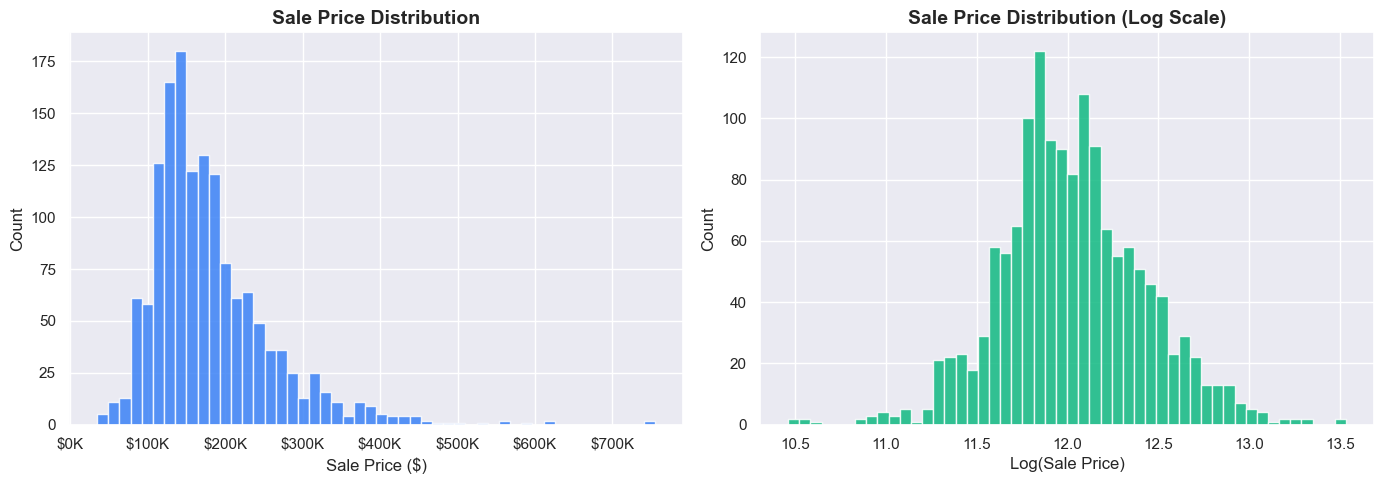

In [4]:
# Sale Price Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['SalePrice'], bins=50, color='#3b82f6', alpha=0.85, edgecolor='white')
axes[0].set_title('Sale Price Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Sale Price ($)')
axes[0].set_ylabel('Count')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))

axes[1].hist(np.log1p(df['SalePrice']), bins=50, color='#10b981', alpha=0.85, edgecolor='white')
axes[1].set_title('Sale Price Distribution (Log Scale)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Log(Sale Price)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig(f'{OUT}/price_distribution.png', dpi=150)
plt.show()

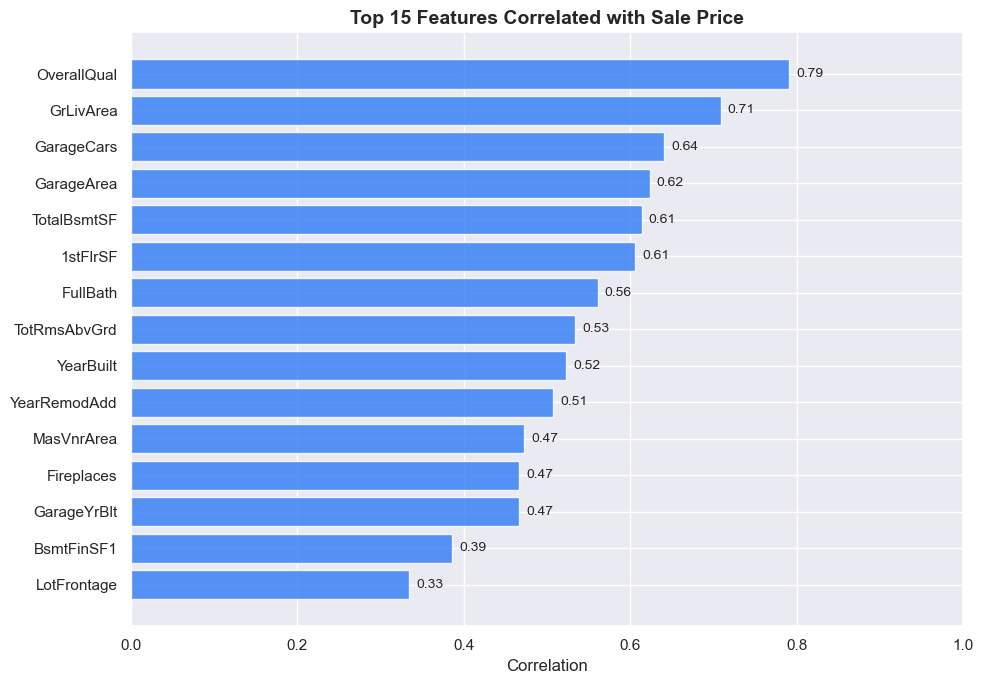

In [5]:
# Top features correlation with SalePrice
corr = df[num_cols].corr()['SalePrice'].drop('SalePrice').abs().sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(corr.index[::-1], corr.values[::-1], color='#3b82f6', alpha=0.85)
ax.bar_label(bars, fmt='{:.2f}', padding=5, fontsize=10)
ax.set_title('Top 15 Features Correlated with Sale Price', fontsize=14, fontweight='bold')
ax.set_xlabel('Correlation')
ax.set_xlim(0, 1)
plt.tight_layout()
plt.savefig(f'{OUT}/feature_correlation.png', dpi=150)
plt.show()

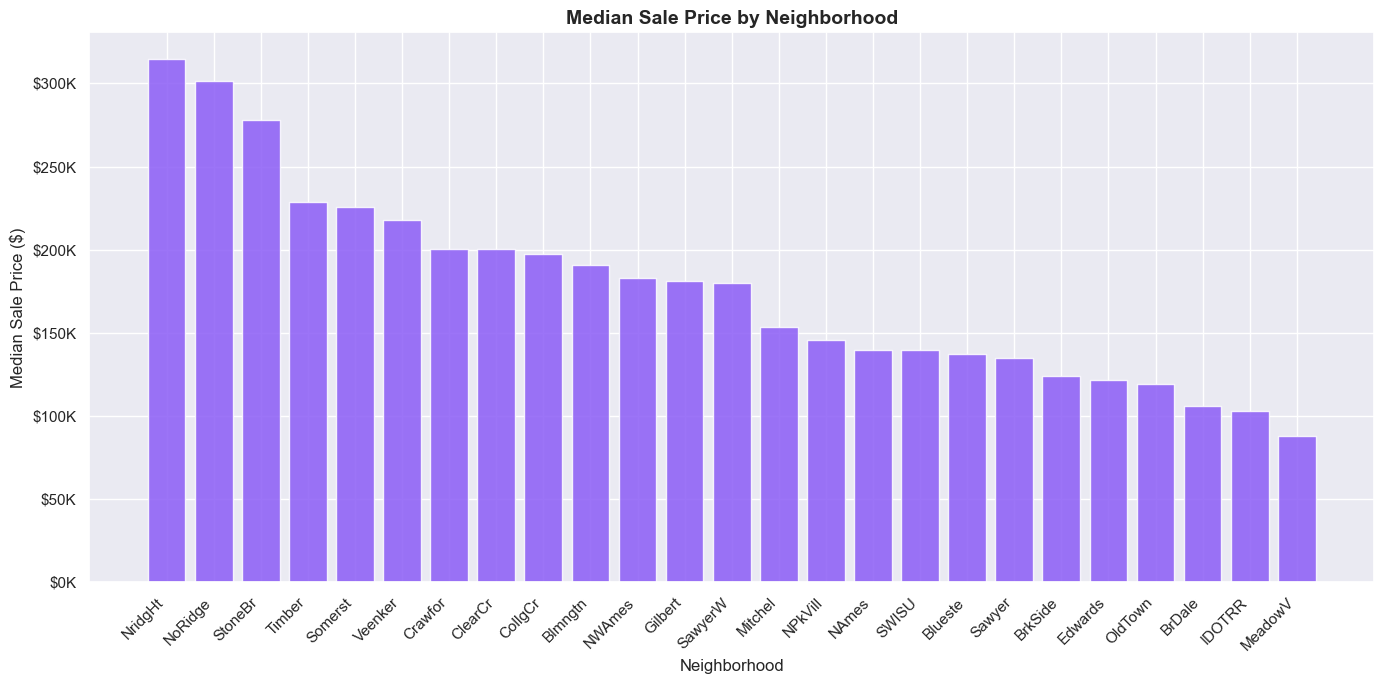

In [6]:
# Price by Neighborhood
neighborhood_avg = df.groupby('Neighborhood')['SalePrice'].median().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 7))
bars = ax.bar(neighborhood_avg.index, neighborhood_avg.values, color='#8b5cf6', alpha=0.85)
ax.set_title('Median Sale Price by Neighborhood', fontsize=14, fontweight='bold')
ax.set_xlabel('Neighborhood')
ax.set_ylabel('Median Sale Price ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(f'{OUT}/price_by_neighborhood.png', dpi=150)
plt.show()

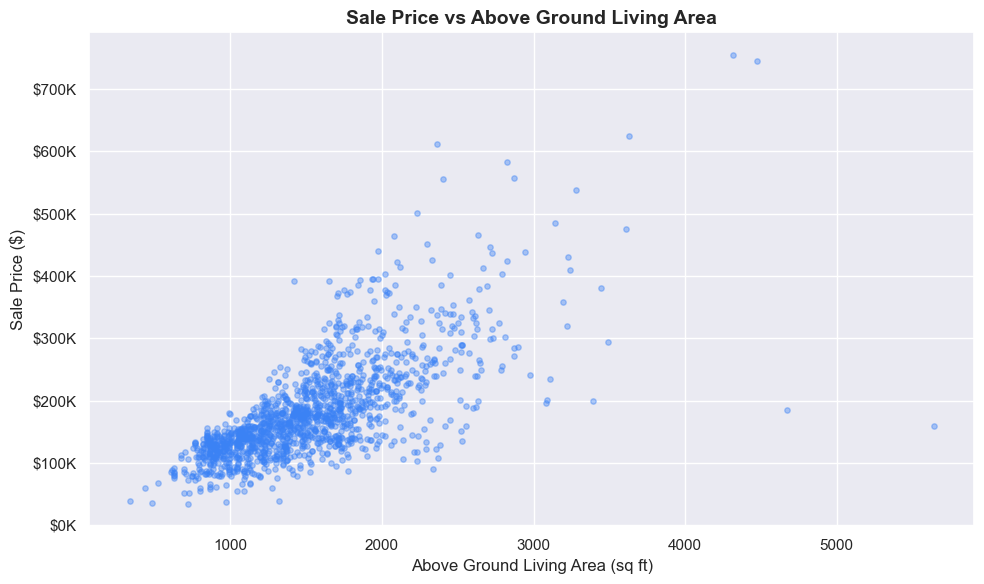

In [7]:
# Price vs Living Area
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(df['GrLivArea'], df['SalePrice'], alpha=0.4, color='#3b82f6', s=15)
ax.set_title('Sale Price vs Above Ground Living Area', fontsize=14, fontweight='bold')
ax.set_xlabel('Above Ground Living Area (sq ft)')
ax.set_ylabel('Sale Price ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
plt.tight_layout()
plt.savefig(f'{OUT}/price_vs_area.png', dpi=150)
plt.show()

## 5. Feature Engineering & Model Preparation

In [8]:
# Encode categorical columns
df_model = df.copy()
le = LabelEncoder()
for col in cat_cols:
    if col in df_model.columns:
        df_model[col] = le.fit_transform(df_model[col].astype(str))

# Features and target
X = df_model.drop(['SalePrice', 'Id'], axis=1, errors='ignore')
y = np.log1p(df_model['SalePrice'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'Train size : {X_train.shape[0]}')
print(f'Test size  : {X_test.shape[0]}')
print(f'Features   : {X_train.shape[1]}')

Train size : 1168
Test size  : 292
Features   : 73


## 6. Model Training & Evaluation

In [9]:
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression' : Ridge(alpha=10),
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    r2   = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae  = mean_absolute_error(y_test, y_pred)
    results[name] = {'R2': r2, 'RMSE': rmse, 'MAE': mae, 'pred': y_pred}
    print(f'{name}')
    print(f'  R2   : {r2:.4f}')
    print(f'  RMSE : {rmse:.4f}')
    print(f'  MAE  : {mae:.4f}')
    print()

Linear Regression
  R2   : 0.8743
  RMSE : 0.1532
  MAE  : 0.1061

Ridge Regression
  R2   : 0.8743
  RMSE : 0.1532
  MAE  : 0.1052



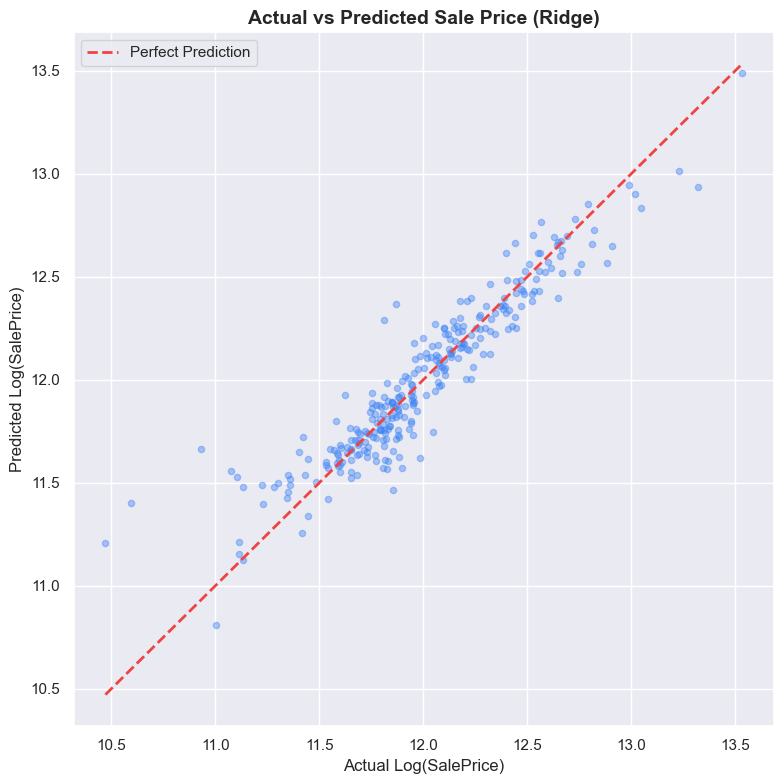

In [10]:
# Actual vs Predicted - Ridge
y_pred_ridge = results['Ridge Regression']['pred']

fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(y_test, y_pred_ridge, alpha=0.4, color='#3b82f6', s=20)
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='#ef4444', linewidth=2, linestyle='--', label='Perfect Prediction')
ax.set_title('Actual vs Predicted Sale Price (Ridge)', fontsize=14, fontweight='bold')
ax.set_xlabel('Actual Log(SalePrice)')
ax.set_ylabel('Predicted Log(SalePrice)')
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig(f'{OUT}/actual_vs_predicted.png', dpi=150)
plt.show()

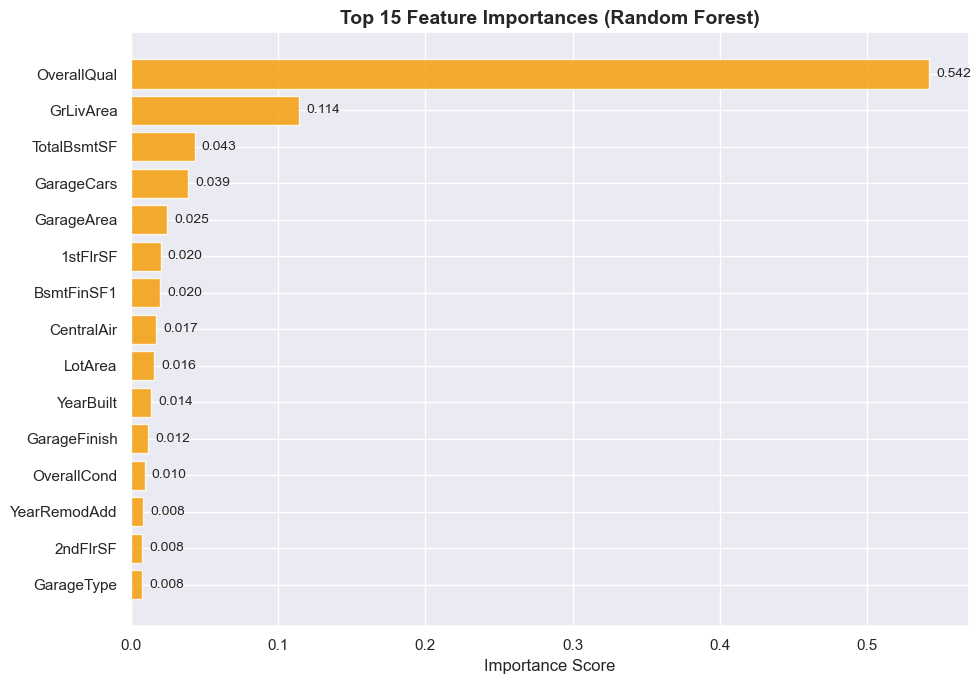

In [11]:
# Feature Importance - Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

importance = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(importance.index[::-1], importance.values[::-1], color='#f59e0b', alpha=0.85)
ax.bar_label(bars, fmt='{:.3f}', padding=5, fontsize=10)
ax.set_title('Top 15 Feature Importances (Random Forest)', fontsize=14, fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig(f'{OUT}/feature_importance.png', dpi=150)
plt.show()

## 7. Key Statistics

In [12]:
best_model = max(results, key=lambda x: results[x]['R2'])

print('=' * 50)
print('       HOUSEPRICER - KEY STATISTICS')
print('=' * 50)
print(f'  Total Houses      : {len(df)}')
print(f'  Features Used     : {X.shape[1]}')
print(f'  Avg Sale Price    : ${df["SalePrice"].mean():,.0f}')
print(f'  Median Sale Price : ${df["SalePrice"].median():,.0f}')
print(f'  Price Range       : ${df["SalePrice"].min():,.0f} - ${df["SalePrice"].max():,.0f}')
print(f'  Best Model        : {best_model}')
print(f'  Best R2 Score     : {results[best_model]["R2"]:.4f}')
print(f'  Best RMSE         : {results[best_model]["RMSE"]:.4f}')
print('=' * 50)

       HOUSEPRICER - KEY STATISTICS
  Total Houses      : 1460
  Features Used     : 73
  Avg Sale Price    : $180,921
  Median Sale Price : $163,000
  Price Range       : $34,900 - $755,000
  Best Model        : Ridge Regression
  Best R2 Score     : 0.8743
  Best RMSE         : 0.1532


---
**Tools:** Python - Pandas - NumPy - Scikit-learn - Matplotlib - Seaborn  
**Author:** Berke Arda Turk